**Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Install dan Import Library**



In [2]:
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import xgboost as xgb
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

**Tentukan Path Folder di Drive**

In [3]:
# Ganti dengan path folder Anda yang berisi file CSV
folder_path = '/content/drive/MyDrive/tga_anisa/'  # <-- SESUAIKAN


**Baca Semua File CSV dan Gabungkan**

In [6]:
# Cari semua file CSV di folder
file_pattern = os.path.join(folder_path, '*.csv')
csv_files = glob.glob(file_pattern)

print(f"Ditemukan {len(csv_files)} file CSV:")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

# Baca dan gabungkan
df_list = []
for file in csv_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)
    print(f"  Memuat {os.path.basename(file)}: {len(df_temp)} baris")

df_raw = pd.concat(df_list, ignore_index=True)
print(f"\nTotal data gabungan: {len(df_raw)} baris")
df_raw.head()

Ditemukan 22 file CSV:
  - kelvin.csv
  - alifi.csv
  - landa.csv
  - padil.csv
  - alam.csv
  - fathur.csv
  - dina.csv
  - nisa.csv
  - sofi.csv
  - ayuk.csv
  - sutri.csv
  - imu_2026-06-01.csv
  - imu_2026-06-01(fatehh).csv
  - nisaMPUDika.csv
  - imu_2026-06-01(padli).csv
  - imu_sultan_nisa.csv
  - imu_Yunda_nisa.csv
  - imu_2026-06-01(Rina).csv
  - imu_2026-06-01(Adnin).csv
  - NisaMPUArlin.csv
  - NIsaMPUFatim.csv
  - NisaMPUNahwa.csv
  Memuat kelvin.csv: 1498 baris
  Memuat alifi.csv: 7119 baris
  Memuat landa.csv: 830 baris
  Memuat padil.csv: 939 baris
  Memuat alam.csv: 1480 baris
  Memuat fathur.csv: 1203 baris
  Memuat dina.csv: 978 baris
  Memuat nisa.csv: 1500 baris
  Memuat sofi.csv: 1258 baris
  Memuat ayuk.csv: 1203 baris
  Memuat sutri.csv: 1495 baris
  Memuat imu_2026-06-01.csv: 28 baris
  Memuat imu_2026-06-01(fatehh).csv: 2205 baris
  Memuat nisaMPUDika.csv: 2340 baris
  Memuat imu_2026-06-01(padli).csv: 2162 baris
  Memuat imu_sultan_nisa.csv: 2155 baris
  Memua

,subject_id,nama,date,time,epoch_ms,ts_millis,ax1,ay1,az1,gx1,...,gz2,label,datetime,mpu_id,ax,ay,az,gx,gy,gz
0,SUBJ002,Kelvin,2026-05-21,17:49:00.437000,1.269280e+09,125437.0,0.94507,-0.09253,0.35767,-16.519,...,2.046,ergonomis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SUBJ002,Kelvin,2026-05-21,17:49:00.637000,1.269280e+09,125637.0,0.92236,0.00488,0.28931,18.901,...,1.969,ergonomis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SUBJ002,Kelvin,2026-05-21,17:49:00.837000,1.269280e+09,125837.0,0.94409,-0.03857,0.29614,-10.580,...,-3.008,ergonomis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SUBJ002,Kelvin,2026-05-21,17:49:00.037000,1.269279e+09,126037.0,0.99463,-0.06274,0.23975,10.641,...,-2.916,ergonomis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SUBJ002,Kelvin,2026-05-21,17:49:00.237000,1.269280e+09,126237.0,1.02319,-0.01245,0.21362,16.168,...,-0.473,ergonomis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Inspeksi Awal**

In [7]:
print("Shape:", df_raw.shape)
print("\nInfo kolom:")
df_raw.info()
print("\nDistribusi label:")
print(df_raw['label'].value_counts())

Shape: (42950, 27)

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42950 entries, 0 to 42949
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subject_id  12384 non-null  object 
 1   nama        12384 non-null  object 
 2   date        12384 non-null  object 
 3   time        12384 non-null  object 
 4   epoch_ms    42950 non-null  float64
 5   ts_millis   42950 non-null  float64
 6   ax1         12384 non-null  float64
 7   ay1         12376 non-null  float64
 8   az1         12382 non-null  float64
 9   gx1         12379 non-null  float64
 10  gy1         12358 non-null  float64
 11  gz1         12329 non-null  float64
 12  ax2         12384 non-null  float64
 13  ay2         12382 non-null  float64
 14  az2         12384 non-null  float64
 15  gx2         12363 non-null  float64
 16  gy2         12372 non-null  float64
 17  gz2         12373 non-null  float64
 18  label       42922 non-null  object

**Exploratory Data Analysis (EDA)**




In [8]:
# Cek missing values
missing = df_raw.isnull().sum()
print("Missing values per kolom:\n", missing[missing > 0])

Missing values per kolom:
 subject_id    30566
nama          30566
date          30566
time          30566
ax1           30566
ay1           30574
az1           30568
gx1           30571
gy1           30592
gz1           30621
ax2           30566
ay2           30568
az2           30566
gx2           30587
gy2           30578
gz2           30577
label            28
datetime      12384
mpu_id        12384
ax            12384
ay            12409
az            12395
gx            12444
gy            12443
gz            12451
dtype: int64


In [9]:
# Statistik deskriptif fitur numerik
numeric_cols = ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1',
                'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2']
df_raw[numeric_cols].describe()

,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2
count,12384.000000,12376.000000,12382.000000,12379.000000,12358.000000,12329.000000,12384.000000,12382.000000,12384.000000,12363.000000,12372.000000,12373.000000
mean,0.944405,0.000345,0.095385,-1.804661,0.300268,-0.067519,0.940815,0.163345,0.436035,-1.011470,0.964159,1.325585
std,0.095801,0.112707,0.395808,4.130345,7.195078,2.556592,0.031326,0.148560,0.134258,5.720659,5.627456,3.159789
min,0.482420,-0.424800,-1.107180,-48.893000,-81.366000,-25.588000,-0.741210,-0.494380,-0.462400,-120.267000,-97.969000,-73.710000
25%,0.913330,-0.066650,0.101560,-2.580000,-0.435000,-0.664000,0.927250,0.074950,0.332280,-2.046000,0.206000,0.756000
50%,0.968260,0.010250,0.232910,-1.779000,0.359000,-0.092000,0.944090,0.206300,0.431400,-0.916000,1.046000,1.344000
75%,0.999270,0.099120,0.310300,-0.947000,1.145000,0.458000,0.959470,0.267090,0.527590,0.198000,1.954000,1.901000
max,1.263430,0.337160,0.864010,44.824000,82.603000,25.733000,1.210450,0.540040,0.928710,109.939000,83.855000,70.786000


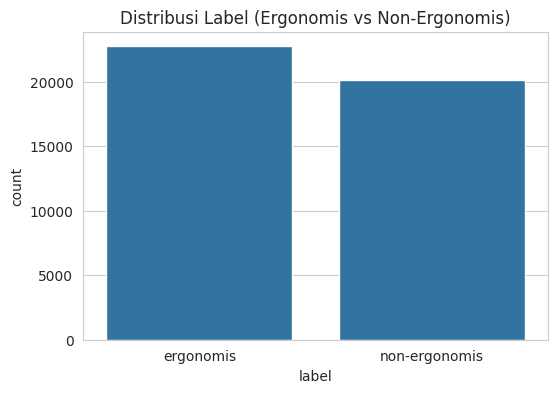

In [10]:
# Visualisasi distribusi label
plt.figure(figsize=(6,4))
sns.countplot(data=df_raw, x='label')
plt.title('Distribusi Label (Ergonomis vs Non-Ergonomis)')
plt.show()

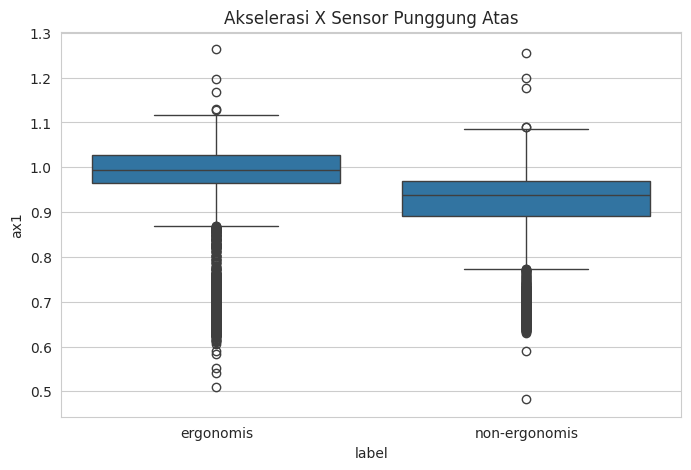

In [11]:
# Boxplot akselerasi X sensor1 per label
plt.figure(figsize=(8,5))
sns.boxplot(data=df_raw, x='label', y='ax1')
plt.title('Akselerasi X Sensor Punggung Atas')
plt.show()

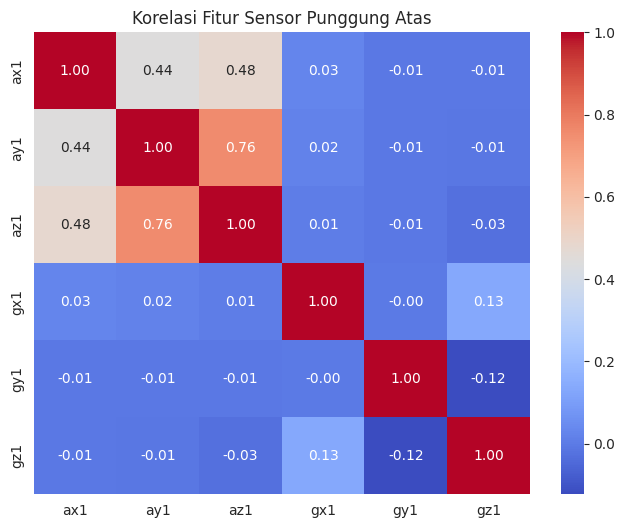

In [12]:
# Korelasi antar fitur (contoh sensor1)
corr = df_raw[['ax1','ay1','az1','gx1','gy1','gz1']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Fitur Sensor Punggung Atas')
plt.show()

**Preprocessing & Feature Engineering**

In [13]:
# Data sudah dalam format merged (ax1, ay1, dll.)
# Tambahkan fitur magnitude
df_raw['acc_mag_s1'] = np.sqrt(df_raw['ax1']**2 + df_raw['ay1']**2 + df_raw['az1']**2)
df_raw['acc_mag_s2'] = np.sqrt(df_raw['ax2']**2 + df_raw['ay2']**2 + df_raw['az2']**2)
df_raw['gyro_mag_s1'] = np.sqrt(df_raw['gx1']**2 + df_raw['gy1']**2 + df_raw['gz1']**2)
df_raw['gyro_mag_s2'] = np.sqrt(df_raw['gx2']**2 + df_raw['gy2']**2 + df_raw['gz2']**2)

feature_cols = ['ax1','ay1','az1','gx1','gy1','gz1',
                'ax2','ay2','az2','gx2','gy2','gz2',
                'acc_mag_s1','acc_mag_s2','gyro_mag_s1','gyro_mag_s2']
print("Fitur yang digunakan:", feature_cols)

Fitur yang digunakan: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'acc_mag_s1', 'acc_mag_s2', 'gyro_mag_s1', 'gyro_mag_s2']


**Encode Label**

In [14]:
le = LabelEncoder()
df_raw['label_enc'] = le.fit_transform(df_raw['label'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
# Biasanya ergonomis=1, non-ergonomis=0

Label mapping: {'ergonomis': np.int64(0), 'non-ergonomis': np.int64(1), nan: np.int64(2)}


**Split Data**

In [15]:
X = df_raw[feature_cols].values
y = df_raw['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {X_train.shape[0]} sampel")
print(f"Test: {X_test.shape[0]} sampel")
print(f"Distribusi target train: {np.bincount(y_train)}")
print(f"Distribusi target test: {np.bincount(y_test)}")

Training: 34360 sampel
Test: 8590 sampel
Distribusi target train: [18205 16133    22]
Distribusi target test: [4551 4033    6]


**Standardisasi (Opsional)**

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

**Training XGBoost (Default)**

In [17]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:,1]

print("Akurasi awal:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, labels=[0, 1], target_names=['ergonomis','non-ergonomis']))

Akurasi awal: 0.6366705471478463

Classification Report:
                precision    recall  f1-score   support

    ergonomis       0.60      0.97      0.74      4551
non-ergonomis       0.89      0.26      0.40      4033

    micro avg       0.64      0.64      0.64      8584
    macro avg       0.74      0.62      0.57      8584
 weighted avg       0.73      0.64      0.58      8584



**Evaluasi: Confusion Matrix & ROC**

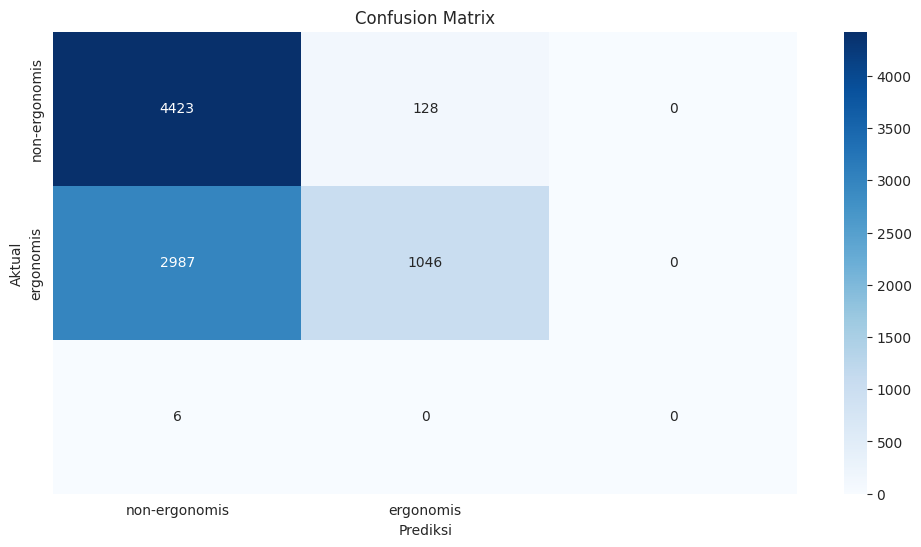

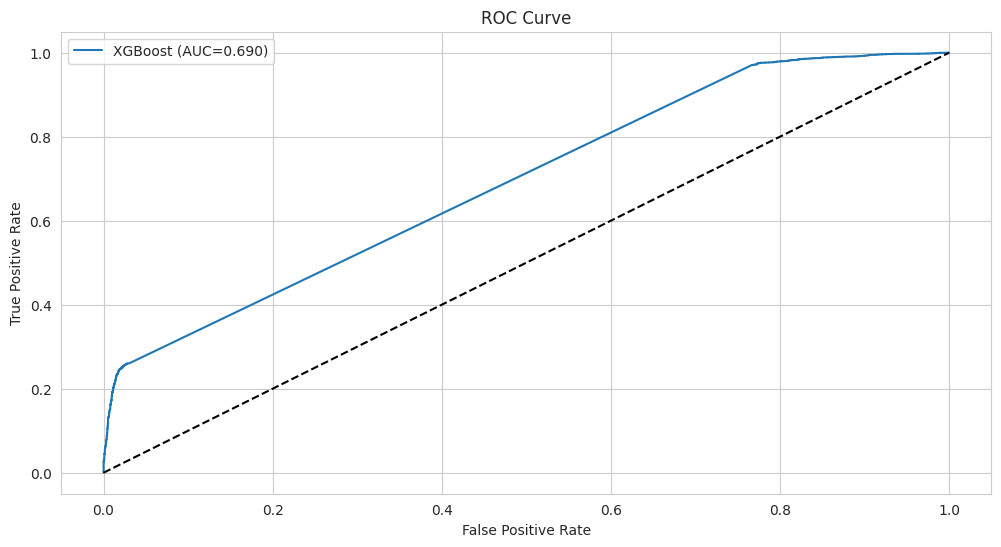

In [18]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-ergonomis','ergonomis'],
            yticklabels=['non-ergonomis','ergonomis'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

# Filter out samples with label 2 (NaN) from y_test and y_pred_proba for ROC curve calculation
valid_indices = (y_test == 0) | (y_test == 1)
y_test_filtered = y_test[valid_indices]
y_pred_proba_filtered = y_pred_proba[valid_indices]

# Recalculate fpr, tpr, and auc with filtered data
fpr, tpr, _ = roc_curve(y_test_filtered, y_pred_proba_filtered)
auc = roc_auc_score(y_test_filtered, y_pred_proba_filtered)
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Feature Importance**

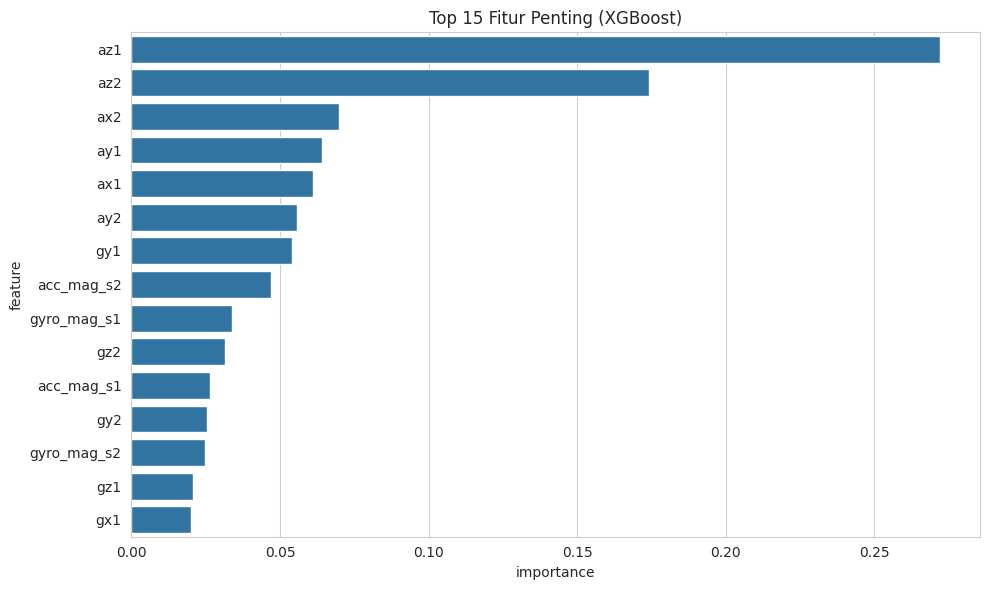

In [19]:
importance = xgb_model.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importance}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title('Top 15 Fitur Penting (XGBoost)')
plt.tight_layout()
plt.show()

**Hyperparameter Tuning (Opsional)**

In [20]:
from sklearn.model_selection import ParameterSampler, cross_val_score
from tqdm.notebook import tqdm

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

n_iter = 50
cv_folds = 5

print(f"Memulai Randomized Search dengan {n_iter} kombinasi, CV={cv_folds} folds")

param_list = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=42))

best_score = -np.inf
best_params = None
best_estimator = None

with tqdm(total=n_iter * cv_folds, desc="Progress fits", unit="fit") as pbar:
    for params in param_list:
        model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, **params)
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_folds, scoring='accuracy')
        mean_score = np.mean(scores)
        pbar.update(cv_folds)
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            best_estimator = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, **params)
            best_estimator.fit(X_train_scaled, y_train)
            pbar.set_postfix(current_best=best_score)

print("\nBest params:", best_params)
print("Best CV accuracy:", best_score)

Memulai Randomized Search dengan 50 kombinasi, CV=5 folds


Progress fits:   0%|          | 0/250 [00:00<?, ?fit/s]


Best params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV accuracy: 0.6440628637951106


**Simpan Model dan Artefak ke Drive**

In [22]:
# Simpan model terbaik (setelah tuning jika dilakukan, atau model default)
best_estimator.save_model('xgb_posture_model.json')
joblib.dump(le, 'label_encoder.pkl')

# Simpan ke Google Drive
drive_path = '/content/drive/MyDrive/'
joblib.dump(best_estimator, drive_path + 'xgb_posture_model.pkl')
best_estimator.save_model(drive_path + 'xgb_posture_model.json')
joblib.dump(le, drive_path + 'label_encoder.pkl')
joblib.dump(scaler, drive_path + 'scaler.pkl')

print("Model dan encoder disimpan ke Google Drive.")

Model dan encoder disimpan ke Google Drive.


**Contoh Prediksi dengan Data Baru**

In [24]:
# Contoh: satu baris data baru dengan 12 fitur + 4 magnitude
sample = np.array([[
    0.95, -0.08, 0.52, 1.2, 2.1, -0.5,   # sensor1
    0.88, -0.51, 0.04, -1.3, 0.9, 0.6,   # sensor2
    np.sqrt(0.95**2+(-0.08)**2+0.52**2),
    np.sqrt(0.88**2+(-0.51)**2+0.04**2),
    np.sqrt(1.2**2+2.1**2+(-0.5)**2),
    np.sqrt((-1.3)**2+0.9**2+0.6**2)
]])

sample_scaled = scaler.transform(sample)
pred = best_estimator.predict(sample_scaled)
proba = best_estimator.predict_proba(sample_scaled)

print("Prediksi label (encoded):", pred)
print("Probabilitas:", proba)
print("Label asli:", le.inverse_transform(pred))

Prediksi label (encoded): [1]
Probabilitas: [[6.299377e-02 9.369762e-01 3.008903e-05]]
Label asli: ['non-ergonomis']
